# Q-Learning on Star Graph (MonteKarloPairGame)
Experiment setup:
- 15 Nodes (Star Graph)
- Q-Learning Agents
- MonteKarloPairGame
- PPReward Model (b=3.0, c=1.0)

In [44]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import sys
import os

# Ensure current directory is in path
sys.path.append(os.getcwd())

from graph_structure import StarGraph, WheelGraph
from learner import QLearner
from reward_model import PPReward
from game_launcher import MonteKarloPairGame

%matplotlib inline

In [45]:
# Configuration
N_NODES = 15
B = 9.0
C = 1.0
K_ANCHORS = 1
N_EPISODES = 1000

# Initialization
graph = StarGraph(N_NODES)
learners = [QLearner(action_space_size=2, learning_rate=0.2, discount_factor=0.9, exploration_rate=0.1) for _ in range(N_NODES)]
reward_model = PPReward(b=B, c=C)

game = MonteKarloPairGame(graph, learners, reward_model, k_anchors=K_ANCHORS)

In [46]:
# Training Loop
cooperation_rates = []

for episode in range(N_EPISODES):
    game.round()
    coop_rate = np.mean(game.strategies)
    cooperation_rates.append(coop_rate)

print("Training Complete")

Training Complete


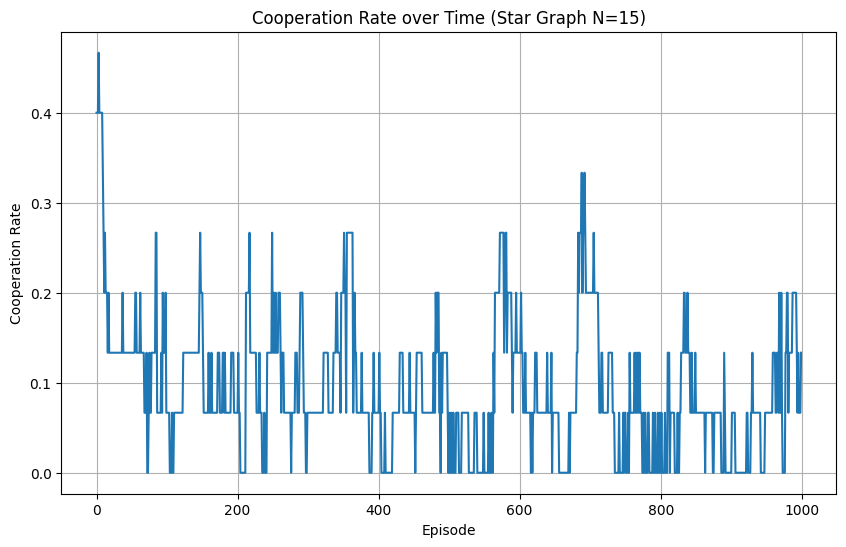

In [47]:
# Visualization
plt.figure(figsize=(10, 6))
plt.plot(cooperation_rates)
plt.title(f'Cooperation Rate over Time (Star Graph N={N_NODES})')
plt.xlabel('Episode')
plt.ylabel('Cooperation Rate')
plt.grid(True)
plt.show()

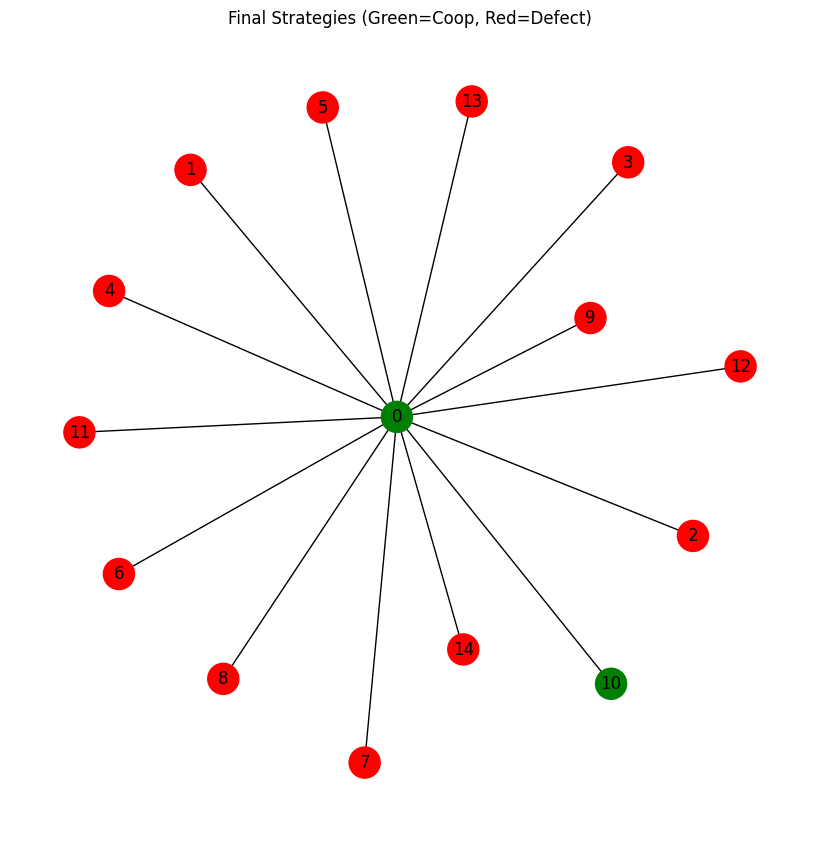

In [48]:
# Final Strategies Visualization
G = graph.G
pos = nx.spring_layout(G)
colors = ['green' if s == 1 else 'red' for s in game.strategies]

plt.figure(figsize=(8, 8))
nx.draw(G, pos, node_color=colors, with_labels=True, node_size=500)
plt.title("Final Strategies (Green=Coop, Red=Defect)")
plt.show()